<a href="https://colab.research.google.com/github/Albertdoc/Machine_Learning_2026/blob/main/Tarea%206.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Parametros

In [ ]:
N_ACTIONS   = 10      # number of arms
N_PLAYS     = 1000    # steps per run
N_RUNS      = 2000    # independent repetitions
EPSILONS    = [0.1, 0.01, 0.009]

Simulacion

In [ ]:
def run_bandit(epsilon, n_actions=N_ACTIONS, n_plays=N_PLAYS, n_runs=N_RUNS,
               rng=None):
    if rng is None:
        rng = np.random.default_rng()

    total_reward  = np.zeros(n_plays)
    total_optimal = np.zeros(n_plays)

    for _ in range(n_runs):
        # True action values drawn from N(0,1)
        q_star   = rng.standard_normal(n_actions)
        opt_act  = np.argmax(q_star)

        Q   = np.zeros(n_actions)   # estimated values
        cnt = np.zeros(n_actions)   # action counts

        for t in range(n_plays):
            # ε-greedy action selection
            if rng.random() < epsilon:
                action = rng.integers(n_actions)
            else:
                action = np.argmax(Q)

            # Reward drawn from N(Q*(a), 1)
            reward = q_star[action] + rng.standard_normal()

            # Incremental sample-mean update
            cnt[action] += 1
            Q[action]   += (reward - Q[action]) / cnt[action]

            total_reward[t]  += reward
            total_optimal[t] += (action == opt_act)

    avg_reward  = total_reward  / n_runs
    pct_optimal = total_optimal / n_runs * 100
    return avg_reward, pct_optimal

Experimentos

In [ ]:
rng = np.random.default_rng(seed=42)

results = {}
for eps in EPSILONS:
    print(f"Running ε = {eps} …")
    results[eps] = run_bandit(eps, rng=rng)
print("Done.")

Running ε = 0.1 …
Running ε = 0.01 …
Running ε = 0.009 …
Done.


Visualizacion

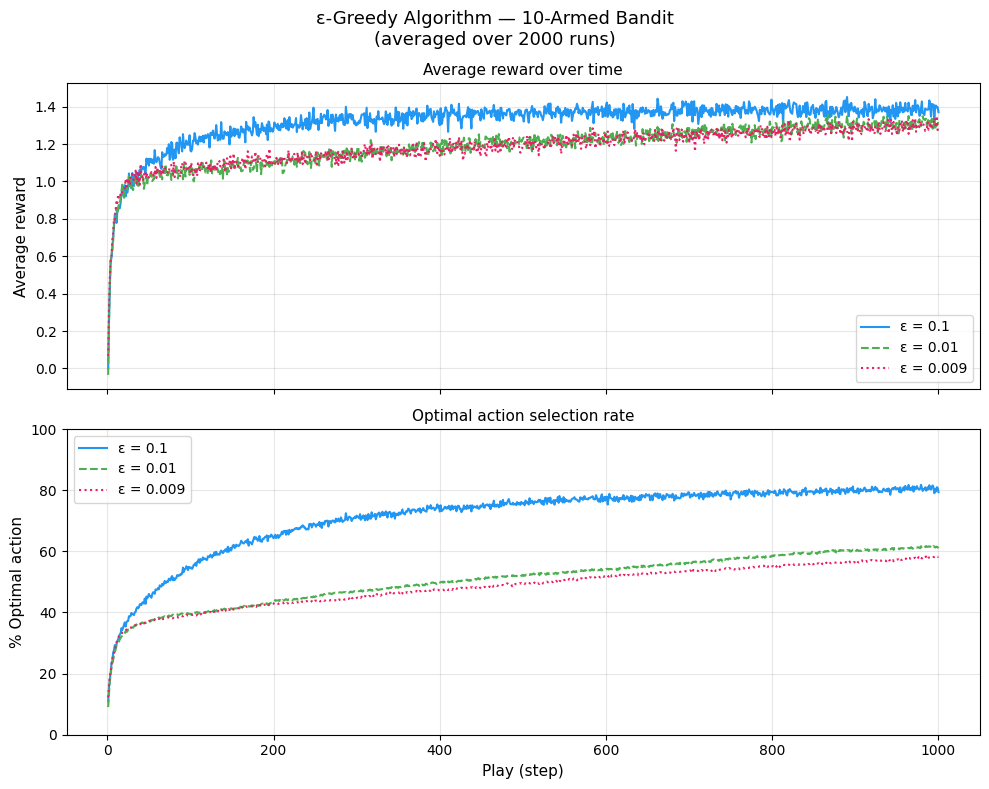

Plot saved to epsilon_greedy_bandit.png


In [ ]:
steps       = np.arange(1, N_PLAYS + 1)
colors      = {0.1: "#2196F3", 0.01: "#4CAF50", 0.009: "#E91E63"}
linestyles  = {0.1: "-",       0.01: "--",       0.009: ":"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("ε-Greedy Algorithm — 10-Armed Bandit\n"
             f"(averaged over {N_RUNS} runs)", fontsize=13)

for eps in EPSILONS:
    avg_r, pct_opt = results[eps]
    label = f"ε = {eps}"
    ax1.plot(steps, avg_r,  label=label, color=colors[eps],
             ls=linestyles[eps], linewidth=1.5)
    ax2.plot(steps, pct_opt, label=label, color=colors[eps],
             ls=linestyles[eps], linewidth=1.5)

    # — Average reward ——
ax1.set_ylabel("Average reward", fontsize=11)
ax1.set_title("Average reward over time", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# — % Optimal action ——
ax2.set_xlabel("Play (step)", fontsize=11)
ax2.set_ylabel("% Optimal action", fontsize=11)
ax2.set_title("Optimal action selection rate", fontsize=11)
ax2.set_ylim(0, 100)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("epsilon_greedy_bandit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to epsilon_greedy_bandit.png")